# Logistic Regression

- Explain Logit Model
    * Calculation of Logistic Regression Model
    * Logit Model Estimation (Maximum Likelihood Estimation)

- Visualization of Logit Functioln on Binary Data: Logit Fits Better
- Interpreting Results
    * Inference
    * Prediction
- Addtional Model Measurement 
    * Chi-square Test
    * Pseudo R2
        - McFadden R2, 
        - Cox and Snell R2,
        - Nagelklerke R2
- Class Imbalance

## Logit Model Explained

### Logit Model ###

**Underlying Logic of Logistic Regression**
Unlike linear regression, which outputs a continuous number value, logistic regression outputs probabilities that are constrained between 0 and 1. This is achieved using the logistic function, also known as the sigmoid function. The logistic function ensures that the output values (probabilities) are within the 0 to 1 range, which makes them interpretable as probabilities.

**Calculation of Logic Model**

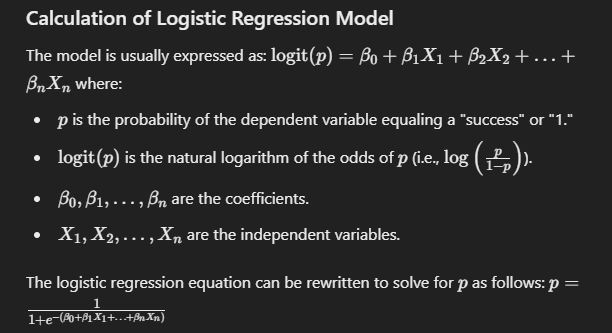

**Explanation of p(X) vs. logit(p)**
- **Logistic Fuction**
    * The logistic function is used to ensure that the probability predictions remain between 0 and 1. In logistic regression, we model the log-odds, logit(𝑝), as a linear combination of the predictors:

    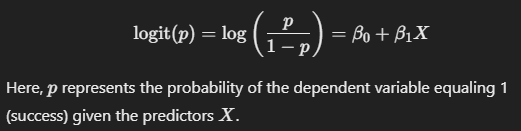

- **Transforming Back to Probability Space**
    * The logistic regression model directly models the log-odds as a linear function. To transform the log-odds back to the probability space, the logistic function is used:

    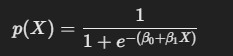

    
- **Probability of Winning, Losing, and Odds**

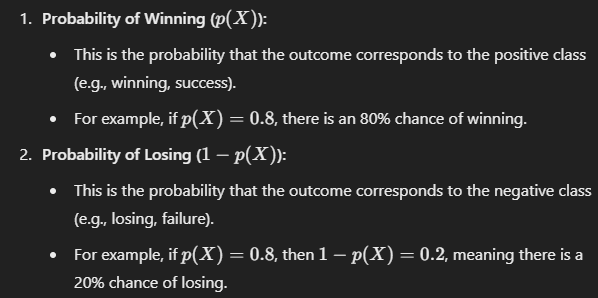

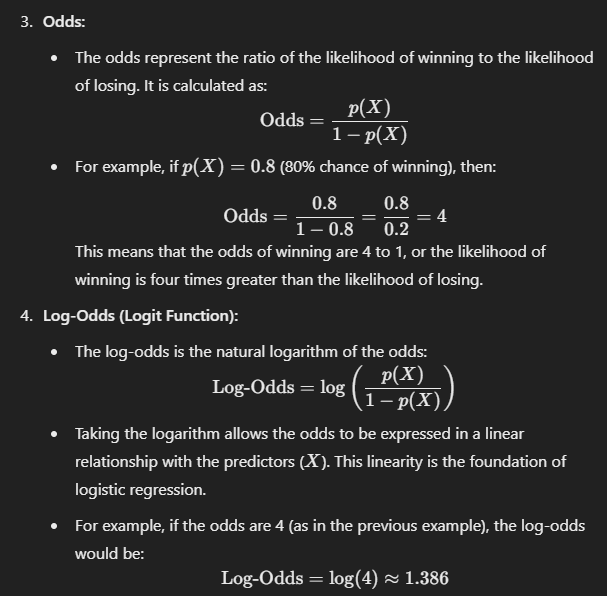

* **Intuition**
    - The log-odds transform probabilities (which are bounded between 0 and 1) into a continuous range (−∞,∞). This transformation is useful for modeling because it allows us to relate the predictors linearly to the log-odds of the outcome.
    - High positive log-odds indicate a high probability of success (𝑝(𝑋) close to 1).
    - Negative log-odds indicate a low probability of success (𝑝(𝑋) close to 0).

### Logit Model Estimation ###
* Logit Model is estimated by a technique called Maximum Likelihood
* This technique maximizes the following likelihood function to derive estimates of the coefficients.

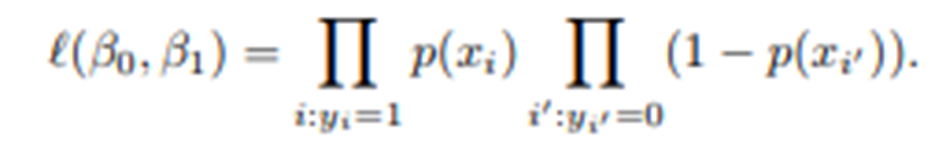

**Maximum Likelihood Estimation (MLE)**
- **Underlying Concept:**
    * In logistic regression, we want to find the parameters (𝛽0,𝛽1,…) that best explain the observed outcomes based on the predictors.
    * MLE aims to find the parameter values that maximize the likelihood that the observed data would occur under the model specified by those parameters.

- **Process**
    * Likelihood Function: The likelihood function (𝐿) measures the "likelihood" of the observed data given a set of parameters. In logistic regression, it's defined as the product of probabilities for all observed data points, where each probability is derived from the logistic function.
    * Maximization: You choose the values of 𝛽0,𝛽1,,… that maximize this likelihood function.

- **The Likelihood Function in Logistic Regression**

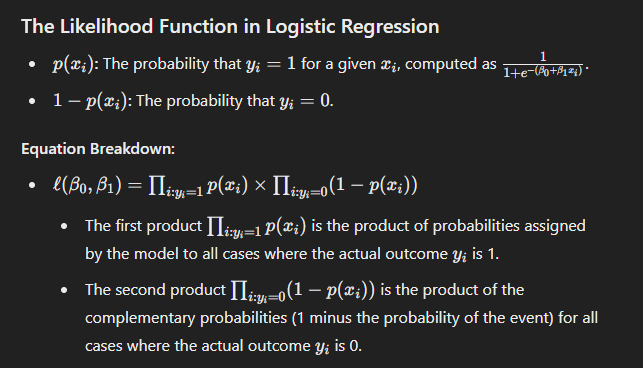

- **Understanding the Likelihood Function**

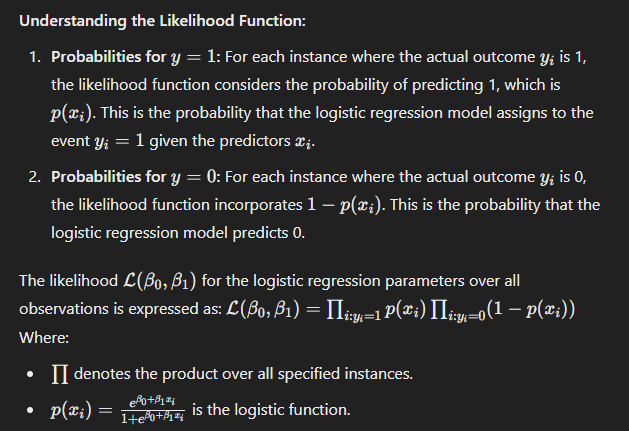

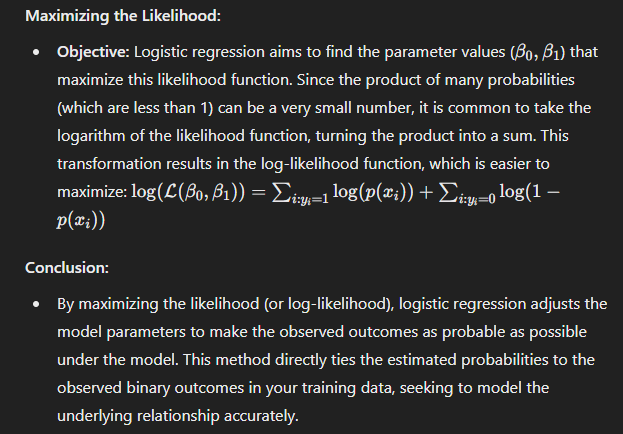

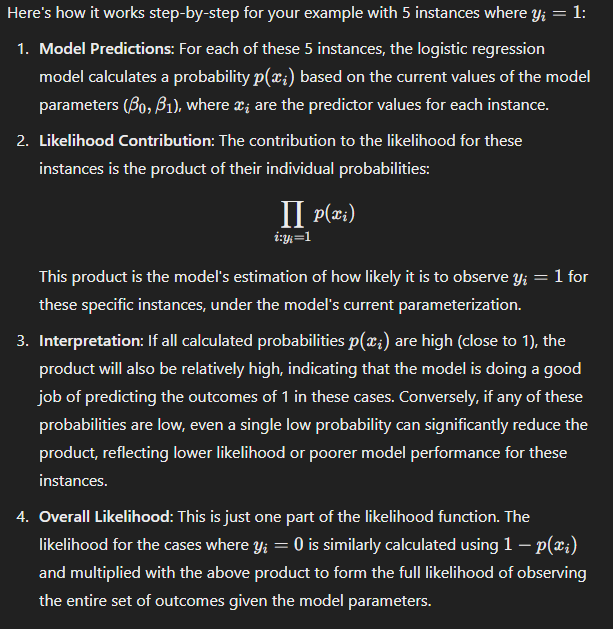

- **Intuition**
    * The likelihood function will be high when the model assigns high probabilities to the true outcomes. For example, if the actual outcome is 1 and the model predicts a high probability of 1, this contributes positively to the likelihood function.
    * By maximizing this function with respect to the parameters (𝛽), we calibrate the model to best fit the data.

### How does Logic Model and MLE work together? ###
**Logit Function**

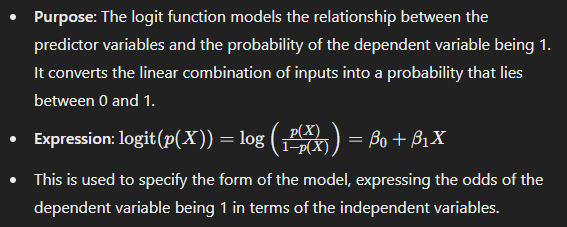

**Maximum Likelihood Estimation (MLE)**

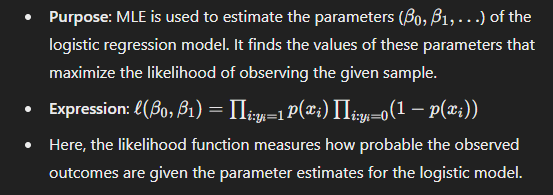

**Integration of Both Components**
    - The logit function sets up the logistic regression model, defining how the probabilities are calculated from the predictors.
    - MLE then uses the likelihood function to find the best parameters (𝛽0,𝛽1,…) that fit the actual data, i.e., those that make the observed data most likely under the logistic model framework.

**Deeper Explination**
1. The Logit Function: Transforms the relationship between the predictor(s) and the outcome into a probability that lies between 0 and 1. This function essentially calculates the probability that the dependent variable equals 1 given the predictors.

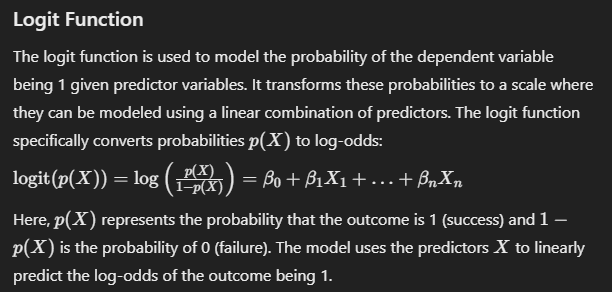

2. Maximum Likelihood Estimation (MLE): Adjusts the parameters (coefficients) of the logit function to find the set of values that make the observed data most likely. The likelihood function evaluates how probable the observed outcomes are under the current set of parameters, and the MLE seeks to maximize this probability across all observations.

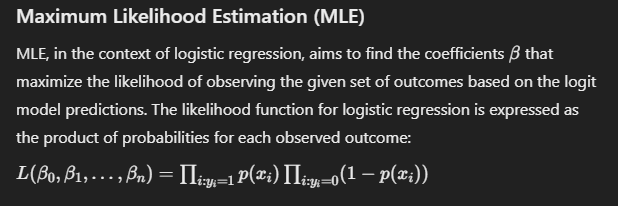

**Linking MLE and the Logit Function**

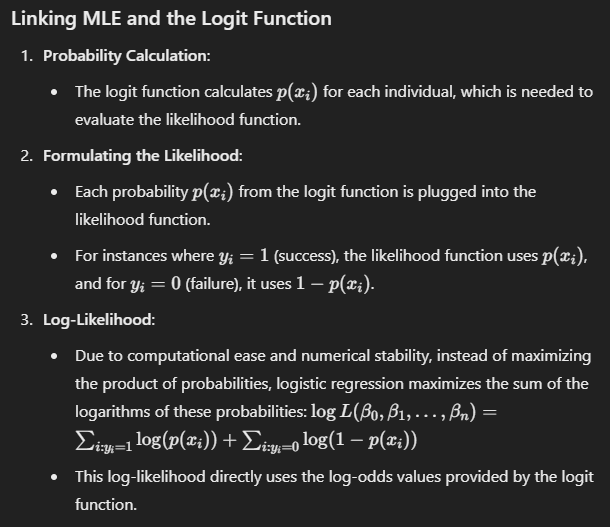

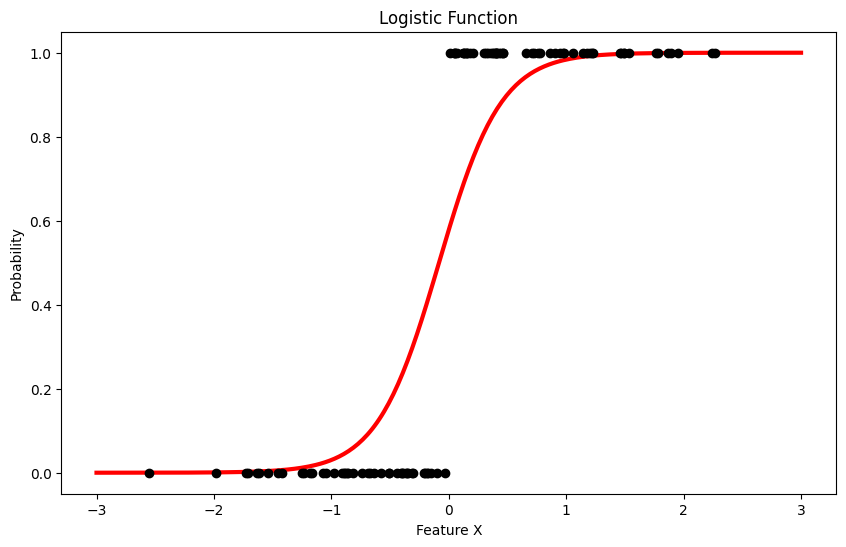

In [1]:
# Code example for Logisric Model Implementation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Generating synthetic binary classification data
np.random.seed(0)
X = np.random.normal(0, 1, (100, 1))
y = (X.squeeze() > 0).astype(int)  # Binary outcome

# Logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Predict probabilities
X_test = np.linspace(-3, 3, 300).reshape(-1, 1)
probabilities = model.predict_proba(X_test)[:, 1]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X.squeeze(), y, color='black', zorder=20)
plt.plot(X_test, probabilities, color='red', linewidth=3)
plt.xlabel("Feature X")
plt.ylabel("Probability")
plt.title("Logistic Function")
plt.show()

Intercept: [0.31533157]
Coefficients: [[3.78196602]]


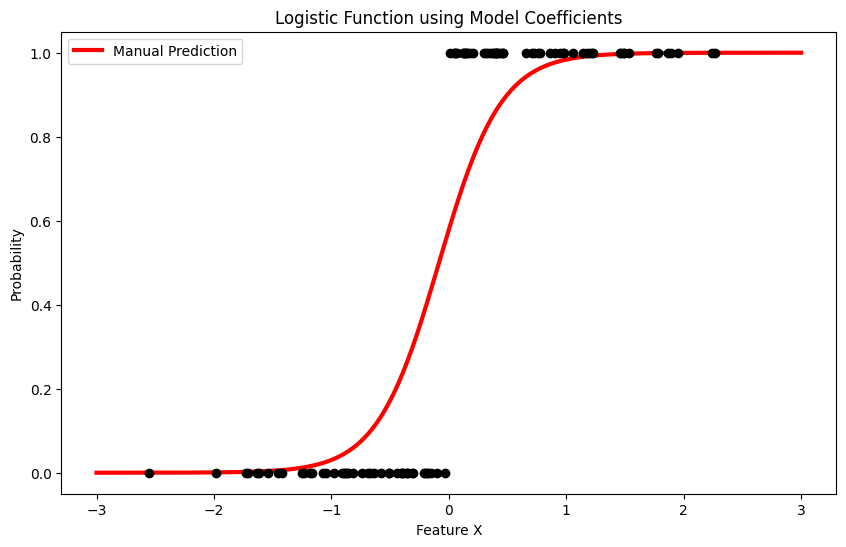

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Generating synthetic binary classification data
np.random.seed(0)
X = np.random.normal(0, 1, (100, 1))
y = (X.squeeze() > 0).astype(int)  # Binary outcome

# Logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Extracting coefficients
coefficients = model.coef_
intercept = model.intercept_

# Displaying coefficients
print("Intercept:", intercept)
print("Coefficients:", coefficients)

# Using coefficients to predict probabilities manually
def logistic_function(X, coefficients, intercept):
    return 1 / (1 + np.exp(-(np.dot(X, coefficients.T) + intercept)))

# Predict probabilities for a range of X values
X_test = np.linspace(-3, 3, 300).reshape(-1, 1)
manual_probabilities = logistic_function(X_test, coefficients, intercept)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X.squeeze(), y, color='black', zorder=20)
plt.plot(X_test, manual_probabilities, color='red', linewidth=3, label='Manual Prediction')
plt.xlabel("Feature X")
plt.ylabel("Probability")
plt.title("Logistic Function using Model Coefficients")
plt.legend()
plt.show()

## Visualization of Logit Functioln on Binary Data: Logit Fits Better
* Based on Lecture Slide Snapshot

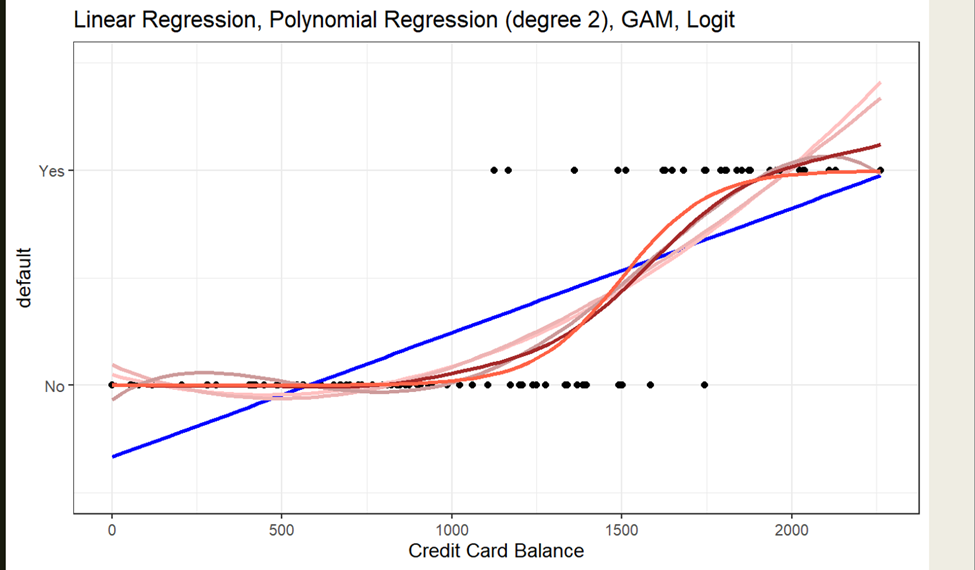

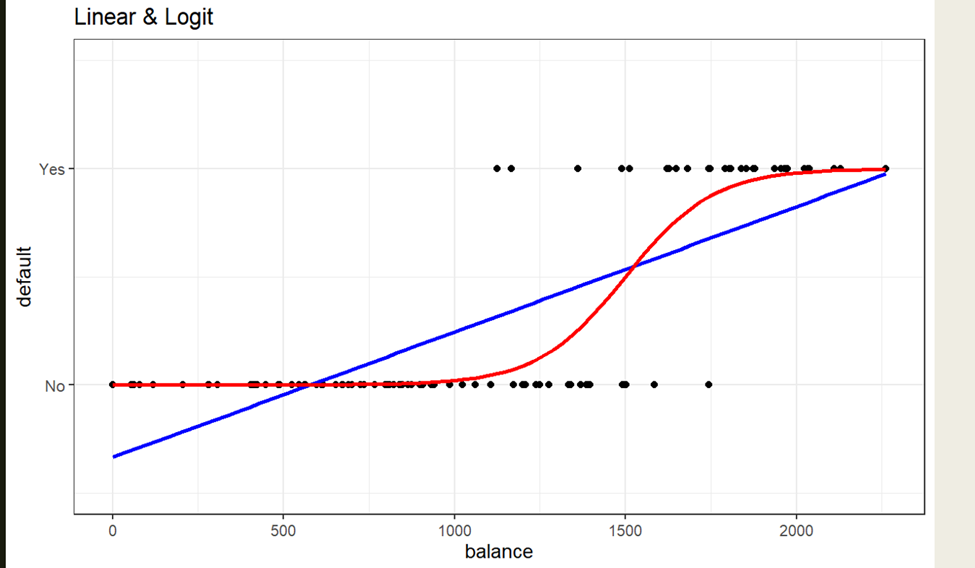

## Interpreting Results
* Inference: Meaningfulness and interpretability of results
    - Statistical tst to examine individual coefficients
    - Statistical significance of z-test indicates an effect
    - If Xi is increased by one unit, the log odds will change by bi units, when the effect of other independent variables is held constant.  
    - The sign of bi will determine whether the likelihood increases (if the sign is positive) or decreases (if the sign is negative) by this amount. 


* Prediction: Quality of predictions
    - **Prediction or Model Performance**
        * In other section, I have already created documentation on model evaluation, so for this section, it would only focuses on these unexplained measurement methods
            - Model Chi-square: Difference of error between baseline and new model; higher and statistically significant is better.
            - Pseudo R2 (designed to mimic  R2 from linear regression)
                * McFadden R2, 
                * Cox and Snell R2,
                * Nagelklerke R2


### Model Chi-square

**Underlying Theory**
The Model Chi-square test in logistic regression is used to assess the goodness of fit of the model. It is calculated as the difference between the log-likelihood of the baseline model (model with no predictors except the intercept) and the log-likelihood of the full model (model with predictors).

**Calculation**

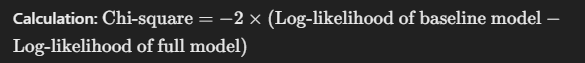

**Benefits and Drawbacks**
- Benefits: Provides a straightforward statistical test to evaluate model improvement over a baseline.
- Drawbacks: Dependent on large sample sizes for reliable inference and doesn't provide information on the magnitude of effect sizes.

In [5]:
# Code Example for Model Chi-square
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Generate synthetic data
np.random.seed(42)
X = np.random.normal(0, 1, (100, 2))
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Fit logistic regression models
model_full = LogisticRegression().fit(X, y)
model_baseline = LogisticRegression().fit(np.ones((X.shape[0], 1)), y)

# Calculate log-likelihoods
prob_full = model_full.predict_proba(X)
prob_baseline = model_baseline.predict_proba(np.ones((X.shape[0], 1)))

log_likelihood_full = -log_loss(y, prob_full, normalize=False)
log_likelihood_baseline = -log_loss(y, prob_baseline, normalize=False)

# Chi-square statistic
chi_square = -2 * (log_likelihood_baseline - log_likelihood_full)
print("Model Chi-square:", chi_square)

Model Chi-square: 105.65619443578488


### Pseudo R-squared

Pseudo R-squared values are alternatives to the R-squared metric used in linear regression, adapted for use in models where traditional R-squared is not applicable such as logistic regression.

**Underlying Theory**
Pseudo R-squared measures provide an indication of how well the model explains the variation in the data, but unlike traditional R-squared, they do not represent the proportion of variance explained.

**Types of Pseudo R-sqaured**
* McFadden's R-squared
* Cox and Snell's R-squared
* Nagelkerke's R-squared

**Benefits and Drawbacks**
- Benefits: Useful for comparing models on the same dataset; more interpretable than log-likelihood values alone.
- Drawbacks: Can be misleading as they do not have a universal benchmark like the traditional R-squared; values can vary widely based on the underlying data and model complexity.


#### McFadden's R-sqaured

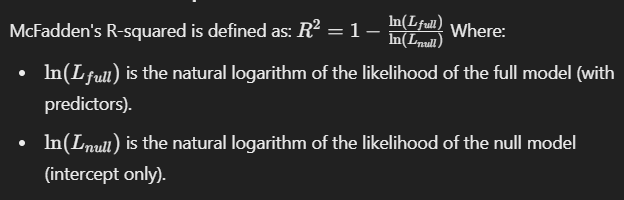

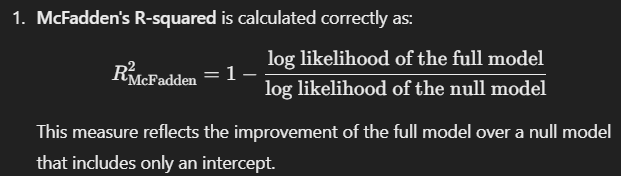

Value Range: 0-1

#### Cox and Snell's R-sqaured

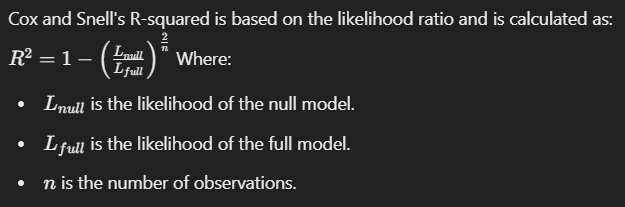

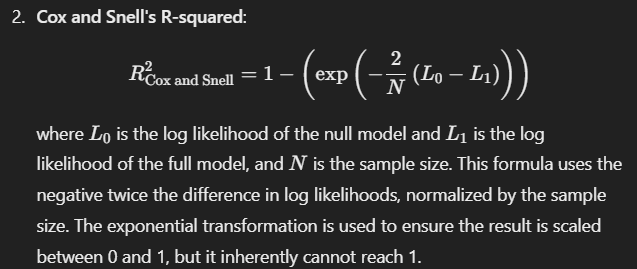

Value Range: 0-less than 1

#### Nagelkerke's R-squared

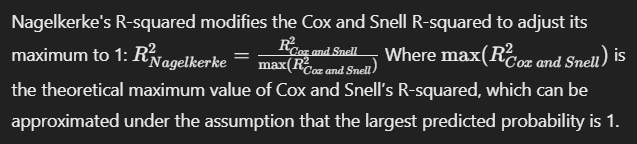

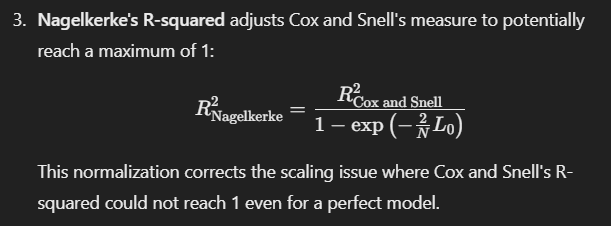

Value Range: 0 to 1

In [8]:
# Code Example for Pseudo R-squared values calculation for a logistic regression model
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Generating synthetic data
np.random.seed(42)
X = np.random.normal(0, 1, (100, 1))
y = (X.squeeze() + np.random.normal(0, 1, 100) > 0).astype(int)

# Fitting logistic regression
model = LogisticRegression()
model.fit(X, y)

# Likelihood of the full model
log_likelihood_full = -log_loss(y, model.predict_proba(X), normalize=False)

# Likelihood of the null model
model_null = LogisticRegression()
model_null.fit(np.ones((100, 1)), y)  # Intercept only
log_likelihood_null = -log_loss(y, model_null.predict_proba(np.ones((100, 1))), normalize=False)

# McFadden's R-squared
r_squared_mcFadden = 1 - (log_likelihood_full / log_likelihood_null)


print("McFadden's R-squared:", r_squared_mcFadden)

McFadden's R-squared: 0.1448823025372563


In [9]:
# Negative log likelihood should be minimized, so converting to positive for clarity in comparisons
log_likelihood_full = -log_likelihood_full
log_likelihood_null = -log_likelihood_null

# Ensure that full model log likelihood is not larger than the null model log likelihood
assert log_likelihood_full <= log_likelihood_null, "Full model likelihood should be better (higher) than null model likelihood."

# Rechecking the computation for R-squared values
r_squared_cox_snell = 1 - np.exp(-2 * (log_likelihood_null - log_likelihood_full) / len(y))
r_squared_nagelkerke = r_squared_cox_snell / (1 - np.exp(-2 * log_likelihood_null / len(y)))

print("Adjusted Cox and Snell's R-squared:", r_squared_cox_snell)
print("Adjusted Nagelkerke's R-squared:", r_squared_nagelkerke)


Adjusted Cox and Snell's R-squared: 0.1815374432074185
Adjusted Nagelkerke's R-squared: 0.24234143345069448


## Other Issues - Class Imbalance
When predicting categorical outcomes, a common problem is class-imbalance, where one level of the outcome is under-represented. Prediction in such cases is particularly hard because simply predicting the majority outcome will generate pretty good results. Consider the following: 
- Predicting Customer Churn: Over a given period of time, most customers are loyal, few leave. 
- Predicting credit card fraud: Most credit card transactions are legitimate
- Medical Imaging: Detecting an abnormal cell amongst hundreds that are healthy. 